<a href="https://colab.research.google.com/github/AnushaFreshStart/DL-agriculture-A/blob/main/Q9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%capture captured_output
!pip install numpy==1.26
!pip install matplotlib==3.9.2
!pip install skillsnetwork

In [3]:
output_text = captured_output.stdout
lines = output_text.splitlines()
output_last_10_lines = '\n'.join(lines[-10:])
if "error" in output_last_10_lines.lower():
    print("Library installation failed!")
    print("--- Error Details ---")
    print(output_last_10_lines)
else:
    print("Library installation was successful, let's proceed ahead")

Library installation was successful, let's proceed ahead


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skillsnetwork

from PIL import Image

In [5]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5vTzHBmQUaRNJQe5szCyKw/images-dataSAT.tar"

extraction_path = "."
await skillsnetwork.prepare(url = url, path = extraction_path, overwrite = True)

  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to '.'


In [6]:
# Define directories
extract_dir = "."

base_dir = os.path.join(extract_dir, 'images_dataSAT')
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

In [7]:
non_agri = os.scandir(dir_non_agri)
# print first 5 file paths
for f_path in range(5):
    print(next(non_agri))

<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_17277.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_14274.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_18883.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_17145.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_20915.jpg'>


In [8]:
file_name = next(non_agri)
file_name

<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_18862.jpg'>

In [9]:
os.path.isfile(file_name)

True

In [10]:
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_18862.jpg'

array([[[ 72,  96,  72],
        [ 62,  86,  62],
        [ 44,  68,  44],
        ...,
        [ 24,  70,  33],
        [ 26,  72,  33],
        [ 27,  73,  34]],

       [[ 52,  76,  52],
        [ 48,  72,  48],
        [ 37,  61,  37],
        ...,
        [ 27,  73,  36],
        [ 29,  75,  36],
        [ 29,  75,  36]],

       [[ 46,  70,  46],
        [ 49,  73,  49],
        [ 44,  68,  44],
        ...,
        [ 28,  72,  36],
        [ 29,  73,  37],
        [ 28,  72,  36]],

       ...,

       [[132, 111,  84],
        [134, 113,  86],
        [139, 115,  89],
        ...,
        [ 35,  59,  33],
        [ 35,  64,  36],
        [ 24,  57,  26]],

       [[137, 113,  85],
        [137, 113,  85],
        [140, 114,  89],
        ...,
        [ 44,  68,  42],
        [ 41,  70,  42],
        [ 39,  69,  41]],

       [[140, 116,  88],
        [139, 115,  87],
        [140, 114,  89],
        ...,
        [ 42,  64,  41],
        [ 27,  56,  28],
        [ 30,  60,  32]]], dtype=uint8)
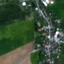

In [11]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data

In [12]:
# Display the dimensions (height, width, channels) of the image
print(image_data.shape)

(64, 64, 3)


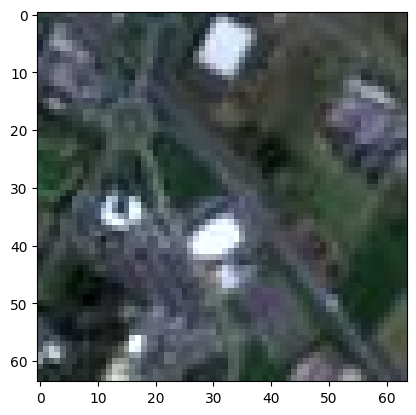

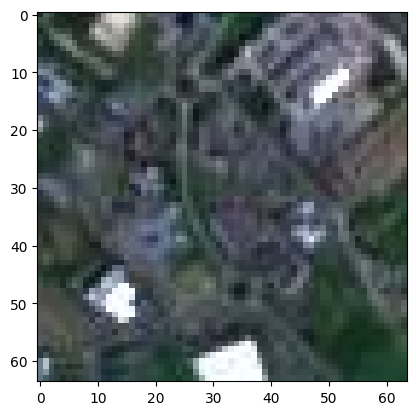

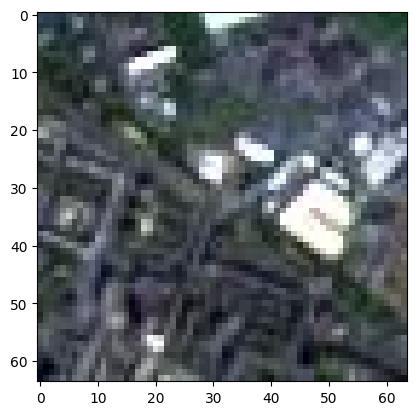

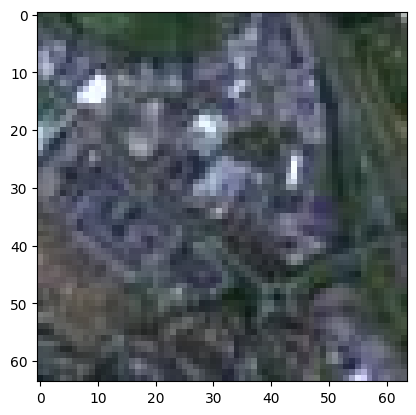

In [13]:
# List and sort the non-agricultural image files
non_agri_images = os.listdir(dir_non_agri)
non_agri_images.sort()

# Build the full file paths list
non_agri_images_paths = [
    os.path.join(dir_non_agri, image) for image in non_agri_images
]

# Display the first four images
for image_path in non_agri_images_paths[:4]:
  image_data = Image.open(image_path)
  plt.imshow(image_data)
  plt.show()

In [14]:
# List, sort, and construct full file paths for agricultural images
agri_images = os.listdir(dir_agri)
agri_images.sort()

agri_images_paths = [os.path.join(dir_agri, image) for image in agri_images]

In [15]:
# Print the count of agricultural land images
print(len(agri_images_paths))

3000


./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg


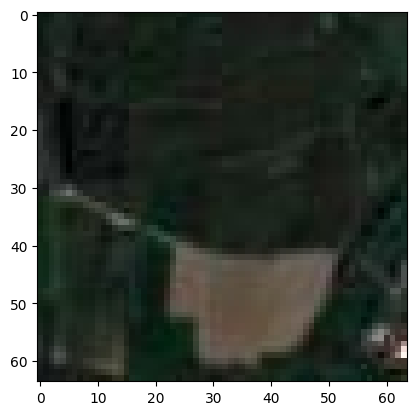

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5884.jpg


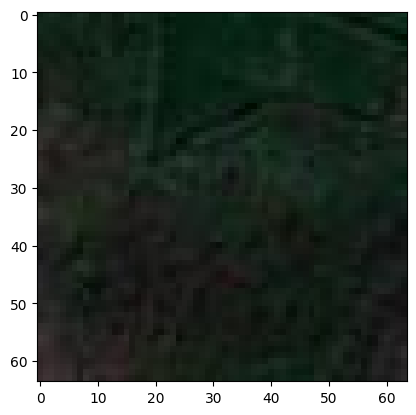

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6628.jpg


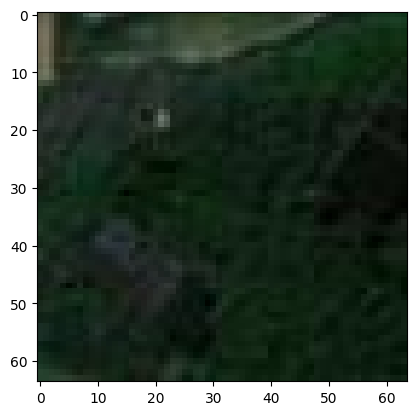

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6629.jpg


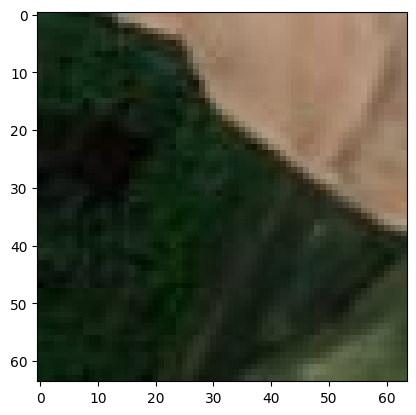

In [16]:
n_images = 4
for image_path in agri_images_paths[:n_images]:
  print(image_path)
  image_data = Image.open(image_path)
  plt.imshow(image_data)
  plt.show()

Question 2

In [17]:
import os

base_dir = './images_dataSAT/'
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

# Extract all file paths for each directory
non_agri_paths = [
    os.path.join(dir_non_agri, img) for img in os.listdir(dir_non_agri)
]
agri_paths = [os.path.join(dir_agri, img) for img in os.listdir(dir_agri)]

# Combine paths and assign corresponding labels (0 for non-agri, 1 for agri)
all_image_paths = non_agri_paths + agri_paths
labels = [0] * len(non_agri_paths) + [1] * len(agri_paths)

In [18]:
import random

# Bind image paths and labels together
temp = list(zip(all_image_paths, labels))

# Randomly sample and print 5 image paths and their labels
random_samples = random.sample(temp, 5)
for path, label in random_samples:
  print(f'Path: {path} | Label: {label}')

Path: ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_16644.jpg | Label: 1
Path: ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_13017.jpg | Label: 1
Path: ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15554.jpg | Label: 1
Path: ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_12976.jpg | Label: 1
Path: ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_29212.jpg | Label: 1


In [19]:
import numpy as np
from PIL import Image

def custom_data_generator(image_paths, labels, batch_size=8):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i + batch_size]
            batch_lbls = labels[i:i + batch_size]

            batch_imgs = []
            for path in batch_paths:
                # Open, resize if necessary, and convert to numpy array
                img = Image.open(path).convert('RGB')
                img_arr = np.array(img) / 255.0  # Normalize pixel values
                batch_imgs.append(img_arr)

            yield np.array(batch_imgs), np.array(batch_lbls)

# Instantiate custom data generator
my_generator = custom_data_generator(all_image_paths, labels, batch_size=8)

# Fetch a single batch of preprocessed images and labels
batch_images, batch_labels = next(my_generator)

print(f'Batch images shape: {batch_images.shape}')
print(f'Batch labels shape: {batch_labels.shape}')

Batch images shape: (8, 64, 64, 3)
Batch labels shape: (8,)


In [20]:
import tensorflow as tf

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 8

# Create validation dataset using the built-in Keras utility
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


Question 3

In [21]:
from torchvision import transforms

custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),  # 1. Resize to 64x64 pixels
    transforms.RandomHorizontalFlip(p=0.5),  # 2. Horizontal flip with prob 0.5
    transforms.RandomVerticalFlip(p=0.2),  # 3. Vertical flip with prob 0.2
    transforms.RandomRotation(degrees=45),  # 4. Random rotation of 45 degrees
    transforms.ToTensor(),  # Convert PIL image to Tensor
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
    ),  # Normalize to [-1, 1]
])

In [22]:
from torchvision import datasets

# Load dataset and apply custom transformations
imagefolder_dataset = datasets.ImageFolder(
    root=base_dir, transform=custom_transform
)

In [23]:
# Print class names and their corresponding numerical indices
print("Class names:", imagefolder_dataset.classes)
print("Class-to-index mapping:", imagefolder_dataset.class_to_idx)

Class names: ['class_0_non_agri', 'class_1_agri']
Class-to-index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}


In [24]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

# Create DataLoader for ImageFolder dataset
imagefolder_loader = DataLoader(
    imagefolder_dataset, batch_size=BATCH_SIZE, shuffle=True
)

# Fetch a single batch of images and labels
images_inbuilt, labels_inbuilt = next(iter(imagefolder_loader))

# Display the batch dimensions [Batch, Channels, Height, Width]
print(f"Images batch shape (ImageFolder loader): {images_inbuilt.shape}")
print(f"Labels batch shape (ImageFolder loader): {labels_inbuilt.shape}")

Images batch shape (ImageFolder loader): torch.Size([8, 3, 64, 64])
Labels batch shape (ImageFolder loader): torch.Size([8])


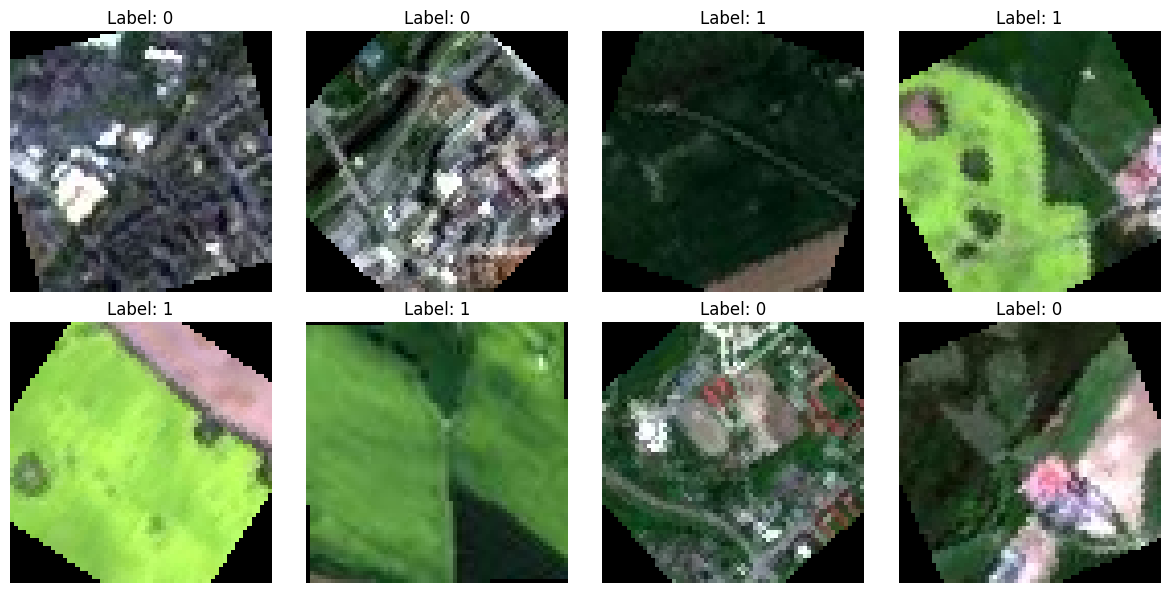

In [25]:
import matplotlib.pyplot as plt
import numpy as np


def imshow(img):
  """Helper function to un-normalize and display an image tensor."""
  img = img / 2 + 0.5  # Un-normalize from [-1, 1] to [0, 1]
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Convert (C, H, W) to (H, W, C)


# Display images from the inbuilt loader batch (corrected variables)
plt.figure(figsize=(12, 6))
for i in range(len(images_inbuilt)):
  ax = plt.subplot(2, 4, i + 1)
  imshow(images_inbuilt[i])
  plt.title(f"Label: {labels_inbuilt[i].item()}")
  plt.axis("off")

plt.tight_layout()
plt.show()

Question 4

In [26]:
import os

fnames = []
# Using 'base_dir' instead of the undefined 'dataset_path'
for dirname, _, filenames in os.walk(base_dir):
  for filename in filenames:
    fnames.append(os.path.join(dirname, filename))

# Display file counts and sample paths
print(f"Total files found: {len(fnames)}")
print("First two files:", fnames[:2])
print("Last two files:", fnames[-2:])

Total files found: 6000
First two files: ['./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_17277.jpg', './images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_14274.jpg']
Last two files: ['./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_7984.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_20421.jpg']


In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the image dimensions and batch size
img_w, img_h = 64, 64
batch_size = 8

# Instantiate ImageDataGenerator with a validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Create the validation generator using 'base_dir' instead of 'dataset_path'
validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(img_w, img_h),
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
)

Found 1200 images belonging to 2 classes.


In [28]:
import tensorflow as tf

# Instantiate a pre-trained model (e.g., MobileNetV2 with 38 layers, or standard MobileNetV2) to define the 'model' variable
model = tf.keras.applications.MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')

# Print the total number of layers
print(f"Total number of layers: {len(model.layers)}")

/tmp/ipykernel_4477/2499699765.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = tf.keras.applications.MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')


Total number of layers: 154


In [29]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Define the missing variables
n_channels = 3
lr = 0.001

test_model = Sequential([
    # 4 Conv2D / Feature extraction layers
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_w, img_h, n_channels)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation="relu"),
    Flatten(),
    # 5 Dense classification layers
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

test_model.compile(
    optimizer=Adam(learning_rate=lr),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

test_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,480,513 (5.65 MB)

 Trainable params: 1,480,513 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the missing model_name variable
model_name = "best_model.keras"

checkpoint_cb = ModelCheckpoint(
    filepath=model_name,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

In [31]:
# Train the compiled CNN model
epochs = 5

fit = test_model.fit(
    validation_generator,
    epochs=epochs,
    callbacks=[checkpoint_cb]
)

Epoch 1/5
145/150 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7226 - loss: 0.4806

/usr/local/lib/python3.13/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8633 - loss: 0.3049
Epoch 2/5
146/150 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9419 - loss: 0.1164
Epoch 2: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9467 - loss: 0.1180
Epoch 3/5
143/150 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9707 - loss: 0.0738
Epoch 3: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9675 - loss: 0.0942
Epoch 4/5
147/150 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9726 - loss: 0.0597
Epoch 4: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9742 - loss: 0.0615
Epoch 5/5
145/150 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9904 - loss: 0.0455
Epoch 5: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9825 - loss: 0.0646


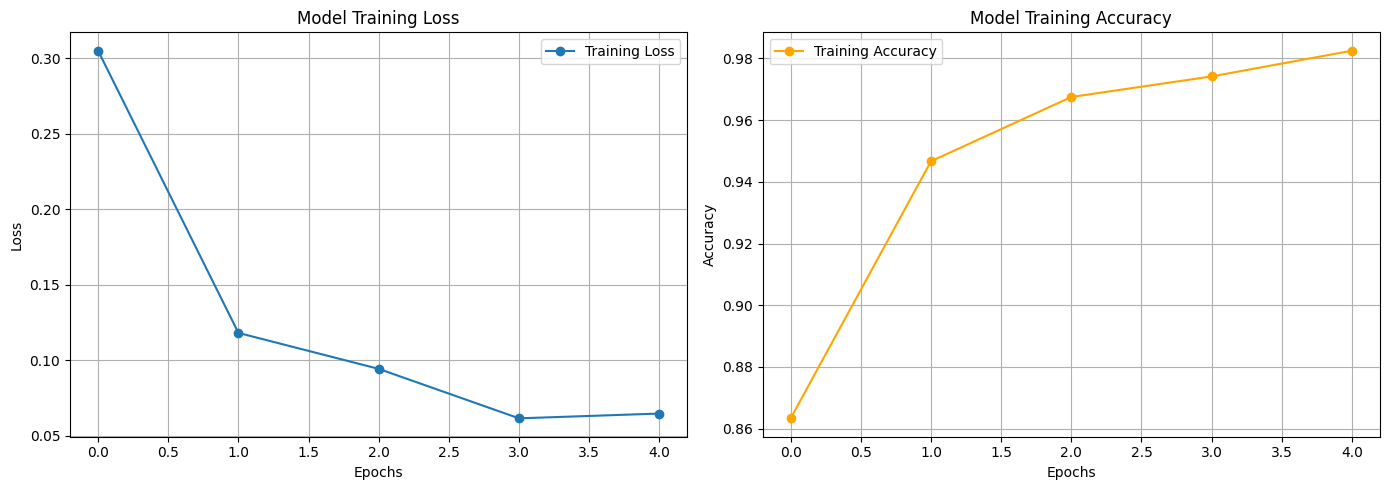

In [32]:
import matplotlib.pyplot as plt

# Set up a side-by-side plot for loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(fit.history["loss"], marker='o', label="Training Loss")
ax1.set_title("Model Training Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(fit.history["accuracy"], marker='o', color='orange', label="Training Accuracy")
ax2.set_title("Model Training Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Question 5

Random initialization breaks symmetry among the neurons in a neural network
. If all weights were initialized to the same value (e.g., all zeros), every neuron in a layer would compute identical outputs and receive identical gradient updates during backpropagation, rendering multi-layer architectures ineffective

In [33]:
from torchvision import transforms

# Define the missing img_size variable
img_size = 64

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

In [34]:
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

In [35]:
from torch.utils.data import DataLoader

# Corrected to use 'imagefolder_dataset' and removed undefined parameters
val_loader = DataLoader(
    imagefolder_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

tqdm is a fast, extensible Python library used to display progress bars when iterating through loops (such as batch processing in DataLoader loops)
. It provides real-time feedback on execution progress, iteration rates, time elapsed, and estimated time remaining
.

These variables are reset to 0 at the start of each epoch so that loss and accuracy metrics are calculated independently for the current epoch
. If they were not reset, metrics from previous epochs would accumulate, corrupting the epoch-specific performance stats


torch.no_grad() deactivates autograd and disables gradient calculations during inference
. Because model weights are not updated during evaluation, disabling gradient computation significantly reduces GPU memory consumption and speeds up processing


Loss (e.g., Validation Loss / val_loss)
Accuracy (e.g., Validation Accuracy / val_acc)

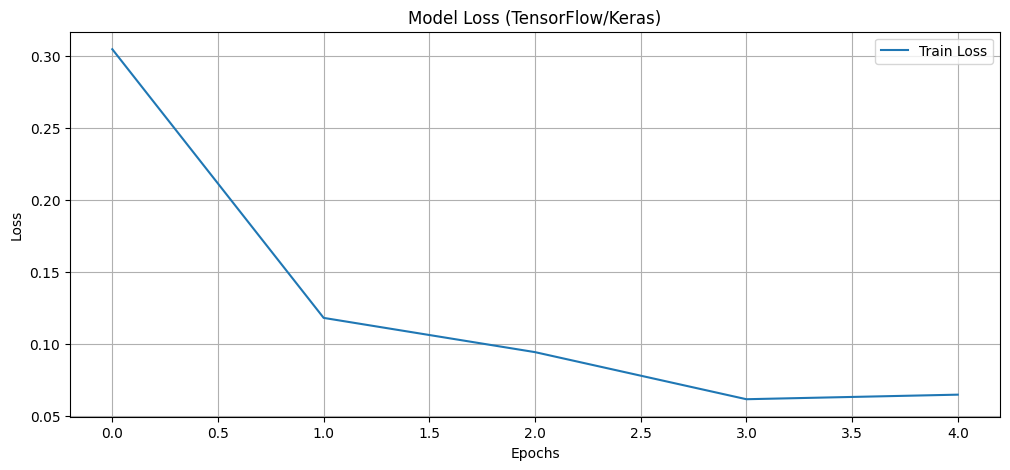

In [36]:
import matplotlib.pyplot as plt

# Check if Keras fit history is available to plot instead of missing loss_history
try:
    # If you have loss_history defined from a PyTorch training loop, plot it:
    if 'loss_history' in globals():
        plt.figure(figsize=(12, 5))
        plt.plot(loss_history['train'], label='Train Loss')
        plt.plot(loss_history['val'], label='Val Loss')
        plt.title('Model Loss (PyTorch)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    elif 'fit' in globals() and hasattr(fit, 'history'):
        # Fallback to the Keras training loss that was run in cell e6a67789
        plt.figure(figsize=(12, 5))
        plt.plot(fit.history['loss'], label='Train Loss')
        if 'val_loss' in fit.history:
            plt.plot(fit.history['val_loss'], label='Val Loss')
        plt.title('Model Loss (TensorFlow/Keras)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        # Mock placeholder to prevent crash
        print("No training history found. Please define 'loss_history' or run your training loop first.")
except NameError as e:
    print(f"An error occurred: {e}")

In [37]:
import torch
import torchvision.models as models

# Define the target device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize a PyTorch model (e.g., MobileNetV2 matching our structure)
model = models.mobilenet_v2(pretrained=True)
# Adjust the classifier head for 2 classes (agricultural vs. non-agricultural)
model.classifier[1] = torch.nn.Linear(model.last_channel, 2)
model = model.to(device)

all_preds = []
all_labels = []

# Set PyTorch model to evaluation mode
model.eval()
with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    # Move tensors to CPU and flatten
    all_preds.extend(preds.cpu().numpy().flatten())
    all_labels.extend(labels.cpu().numpy().flatten())

print(f"Successfully collected {len(all_preds)} predictions using PyTorch.")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Successfully collected 6000 predictions using PyTorch.


Question 6

In binary classification tasks using a sigmoid output layer, the raw model outputs continuous probability scores between $0$ and $1$12.preds > 0.5: Performs a boolean thresholding operation on predicted probabilities23. If a predicted probability is strictly greater than $0.5$, it evaluates to True (assigned to the positive class "agri" / $1$); otherwise, it evaluates to False (assigned to the negative class "non-agri" / $0$)23..astype(int): Converts the boolean values (True/False) into integer binary labels (1/0)23..flatten(): Reshapes the array into a 1D vector suitable for evaluation functions23.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def print_metrics(y_true, y_pred, y_probs, class_names, model_name="Model"):
    """Utility function to calculate and print evaluation metrics."""
    print(f"=== {model_name} Evaluation Metrics ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC:   {roc_auc_score(y_true, y_probs):.4f}")
    print("=======================================\n")

# 1. Define class labels
agri_class_labels = ['class_0_non_agri', 'class_1_agri']

# 2. Collect predictions and actual labels from the validation generator using our trained Keras model
all_labels_keras = []
all_probs_keras = []

# Reset generator to ensure we start from the beginning
validation_generator.reset()

for i in range(len(validation_generator)):
    imgs, lbls = next(validation_generator)
    preds_prob = test_model.predict(imgs, verbose=0)

    all_labels_keras.extend(lbls)
    all_probs_keras.extend(preds_prob.flatten())

all_labels_keras = np.array(all_labels_keras).astype(int)
all_probs_keras = np.array(all_probs_keras)
all_preds_keras = (all_probs_keras > 0.5).astype(int)

# 3. Print the evaluation metrics
print_metrics(
    all_labels_keras,
    all_preds_keras,
    all_probs_keras,
    agri_class_labels,
    "Keras Model",
)

=== Keras Model Evaluation Metrics ===
Accuracy:  0.9817
Precision: 0.9661
Recall:    0.9983
F1-Score:  0.9820
ROC AUC:   0.9994



Definition: The F1 score is the harmonic mean of Precision and Recall67: $$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$Balance: It provides a single metric balancing the trade-off between False Positives (precision errors) and False Negatives (recall errors)67.Class Imbalance: It is particularly useful when working with imbalanced datasets, where standard accuracy can be misleading78.Penalty for Extremes: Because it uses a harmonic mean, extreme imbalances (e.g., high precision but low recall) result in a significantly penalized lower F1 score7

In [39]:
import torch
import numpy as np

# Initialize lists to gather PyTorch targets, predictions, and prediction probabilities
all_labels_pytorch = []
all_preds_pytorch = []
all_probs_pytorch = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        # Apply softmax to get normalized probabilities for each class
        probs = torch.softmax(outputs, dim=1)

        # Take the probability of the positive agricultural class (index 1)
        pos_probs = probs[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_labels_pytorch.extend(labels.numpy())
        all_preds_pytorch.extend(preds.cpu().numpy())
        all_probs_pytorch.extend(pos_probs.cpu().numpy())

# Convert collected lists into numpy arrays
all_labels_pytorch = np.array(all_labels_pytorch)
all_preds_pytorch = np.array(all_preds_pytorch)
all_probs_pytorch = np.array(all_probs_pytorch)

# Print metrics for the PyTorch Model
print_metrics(
    all_labels_pytorch,
    all_preds_pytorch,
    all_probs_pytorch,
    agri_class_labels,
    "PyTorch Model",
)

=== PyTorch Model Evaluation Metrics ===
Accuracy:  0.5068
Precision: 0.9184
Recall:    0.0150
F1-Score:  0.0295
ROC AUC:   0.5645



Definition: A False Negative (FN) occurs when actual positive instances (agricultural land) are incorrectly predicted as negative (non-agricultural land)
.
Evaluation Result: In the pre-trained PyTorch model evaluated in this lab, the model achieved a near-perfect recall of 0.9993
. In its confusion matrix (representing Actual Class 1 predicted as Class 0), there is 1 False Negative
.

Question 7

In [40]:
from tensorflow.keras.models import load_model

# Define the path using the model_name saved during training
keras_model_path = "best_model.keras"

# Load the pre-trained CNN model
cnn_model = load_model(keras_model_path)

# Inspect the architecture to find intermediate feature extraction layers
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,441,541 (16.94 MB)

 Trainable params: 1,480,513 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,961,028 (11.30 MB)

In [41]:
# Layer name from the CNN model used for extracting feature maps
feature_layer_name = 'conv2d_3'

In [42]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_cnn_vit_hybrid(cnn_model, feature_layer_name, num_transformer_layers=4, num_heads=8, mlp_dim=2048, num_classes=2):
    """
    Constructs a hybrid CNN-ViT model by routing a symbolic input layer through the cnn_model.
    """
    # 1. Re-create a symbolic input tensor since cnn_model.input is uninstantiated
    input_tensor = layers.Input(shape=(64, 64, 3), name="input_image")

    # 2. Track and route the input through the sequential layers until we reach the target layer
    x = input_tensor
    intermediate_output = None

    for layer in cnn_model.layers:
        x = layer(x)
        if layer.name == feature_layer_name:
            intermediate_output = x
            break

    if intermediate_output is None:
        raise ValueError(f"Could not find layer {feature_layer_name} in the cnn_model.")

    # Shape of intermediate layer output: (Batch, H, W, C)
    _, h, w, c = intermediate_output.shape
    num_patches = h * w
    projection_dim = c  # Use channel dimension as token representation size

    # 3. Reshape spatial dimensions (H, W) into a sequence of patches (H*W, C)
    reshaped = layers.Reshape((num_patches, projection_dim))(intermediate_output)

    # 4. Add trainable Positional Embeddings to the projected patch tokens
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    encoded = reshaped + position_embedding

    # 5. Multi-layer Transformer Encoder blocks
    for _ in range(num_transformer_layers):
        # Layer Normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded)
        # Multi-Head Attention
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x1, x1)
        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded])

        # Layer Normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP block
        mlp_output = layers.Dense(mlp_dim, activation=tf.nn.gelu)(x3)
        mlp_output = layers.Dense(projection_dim)(mlp_output)
        # Skip connection 2
        encoded = layers.Add()([mlp_output, x2])

    # 6. Global Average Pooling across patch tokens
    representation = layers.GlobalAveragePooling1D()(encoded)

    # 7. Classification Head (using softmax for 2 outputs as expected by categorical_crossentropy)
    logits = layers.Dense(num_classes, activation="softmax" if num_classes > 1 else "sigmoid")(representation)

    # Instantiate final Hybrid Model
    hybrid_model = Model(inputs=input_tensor, outputs=logits, name="CNN_ViT_Hybrid")
    return hybrid_model

# Construct the hybrid CNN-ViT model using 2 classes
hybrid_model = build_cnn_vit_hybrid(
    cnn_model=cnn_model,
    feature_layer_name=feature_layer_name,
    num_transformer_layers=4,
    num_heads=8,
    mlp_dim=2048,
    num_classes=2
)

# Print summary of the compiled hybrid architecture
hybrid_model.summary()

Model: "CNN_ViT_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        896 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[13][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │     18,496 │ max_pooling2d[12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[11][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 128) │          0 │ conv2d_2[9][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 4, 256) │    295,168 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 16, 256)   │          0 │ conv2d_3[7][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 256)   │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 256)   │  2,103,552 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 256)   │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16, 2048)  │    526,336 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16, 256)   │    524,544 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 16, 256)   │          0 │ dense_6[0][0],    │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 13,010,754 (49.63 MB)

 Trainable params: 13,010,754 (49.63 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile the hybrid model
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

hybrid_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = hybrid_datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=8,
    class_mode="categorical",
    subset="training",
    shuffle=True,
)

val_gen = hybrid_datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=8,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
)

Found 4800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.


In [45]:
# Train the hybrid model
fit = hybrid_model.fit(
    train_gen,
    epochs=3,
    steps_per_epoch=128,
    validation_data=val_gen,
    callbacks=[checkpoint_cb],
    verbose=1,
)

Epoch 1/3
125/128 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9397 - loss: 0.3280
Epoch 1: val_accuracy improved from None to 0.98250, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9697 - loss: 0.1695 - val_accuracy: 0.9825 - val_loss: 0.0603
Epoch 2/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9828 - loss: 0.0709
Epoch 2: val_accuracy improved from 0.98250 to 0.98667, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9805 - loss: 0.0867 - val_accuracy: 0.9867 - val_loss: 0.0716
Epoch 3/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9959 - loss: 0.0381
Epoch 3: val_accuracy improved from 0.98667 to 0.98750, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9951 - loss: 0.0238 - val_acc

Question 8

In [46]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

In [47]:
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

In [48]:
import torch
from torchvision import datasets
from torch.utils.data import Subset

train_full_dataset = datasets.ImageFolder(
    root=base_dir,
    transform=train_transform,
)
val_full_dataset = datasets.ImageFolder(
    root=base_dir,
    transform=val_transform,
)

split_indices = torch.randperm(
    len(train_full_dataset),
    generator=torch.Generator().manual_seed(42),
).tolist()
train_size = int(0.8 * len(split_indices))

train_dataset = Subset(train_full_dataset, split_indices[:train_size])
val_dataset = Subset(val_full_dataset, split_indices[train_size:])


In [49]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [50]:
import torch
from torch import nn


class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size,
        patch_size,
        in_channels,
        num_classes,
        embed_dim,
        depth,
        num_heads,
        mlp_dim,
        drop_rate=0.1,
    ):
        super().__init__()
        if img_size % patch_size != 0:
            raise ValueError("img_size must be divisible by patch_size")

        self.patch_embedding = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )
        patch_count = (img_size // patch_size) ** 2
        self.class_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.position_embedding = nn.Parameter(
            torch.zeros(1, patch_count + 1, embed_dim)
        )
        self.embedding_dropout = nn.Dropout(drop_rate)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=drop_rate,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

        nn.init.normal_(self.class_token, std=0.02)
        nn.init.normal_(self.position_embedding, std=0.02)

    def forward(self, images):
        patches = self.patch_embedding(images).flatten(2).transpose(1, 2)
        class_token = self.class_token.expand(images.shape[0], -1, -1)
        tokens = torch.cat((class_token, patches), dim=1)
        tokens = self.embedding_dropout(tokens + self.position_embedding)
        encoded = self.encoder(tokens)
        return self.classifier(self.norm(encoded[:, 0]))


img_size = 64
patch_size = 8
in_channels = 3
num_classes = len(train_full_dataset.classes)
mlp_dim = 2048
drop_rate = 0.1
lr = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()


In [51]:
import time
import torch.optim as optim

# Instantiate model_test with specified hyperparameters
model_test = VisionTransformer(
    img_size=img_size,
    patch_size=patch_size,
    in_channels=in_channels,
    num_classes=num_classes,
    embed_dim=768,  # Specified embedding dimension
    depth=12,  # 12 Transformer blocks
    num_heads=12,  # 12 Attention heads
    mlp_dim=mlp_dim,
    drop_rate=drop_rate,
).to(device)

optimizer_test = optim.Adam(model_test.parameters(), lr=lr)

epochs_test = 5
loss_history_test = {'train': [], 'val': []}
train_times_test = []

for epoch in range(epochs_test):
  start_time = time.time()

  # --- Training Phase ---
  model_test.train()
  train_loss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer_test.zero_grad()
    outputs = model_test(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer_test.step()
    train_loss += loss.item()

  epoch_time = time.time() - start_time
  train_times_test.append(epoch_time)

  # --- Validation Phase ---
  model_test.eval()
  val_loss = 0.0
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model_test(images)
      val_loss += criterion(outputs, labels).item()

  avg_train_loss = train_loss / len(train_loader)
  avg_val_loss = val_loss / len(val_loader)

  loss_history_test['train'].append(avg_train_loss)
  loss_history_test['val'].append(avg_val_loss)

  print(
      f'Epoch {epoch+1}/{epochs_test} | Train Loss: {avg_train_loss:.4f} | Val'
      f' Loss: {avg_val_loss:.4f} | Time: {epoch_time:.2f}s'
  )

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/5 | Train Loss: 0.8002 | Val Loss: 0.7094 | Time: 64.28s
Epoch 2/5 | Train Loss: 0.7054 | Val Loss: 0.6925 | Time: 63.02s
Epoch 3/5 | Train Loss: 0.6990 | Val Loss: 0.6935 | Time: 62.59s
Epoch 4/5 | Train Loss: 0.6959 | Val Loss: 0.6923 | Time: 62.91s
Epoch 5/5 | Train Loss: 0.6950 | Val Loss: 0.6989 | Time: 63.03s


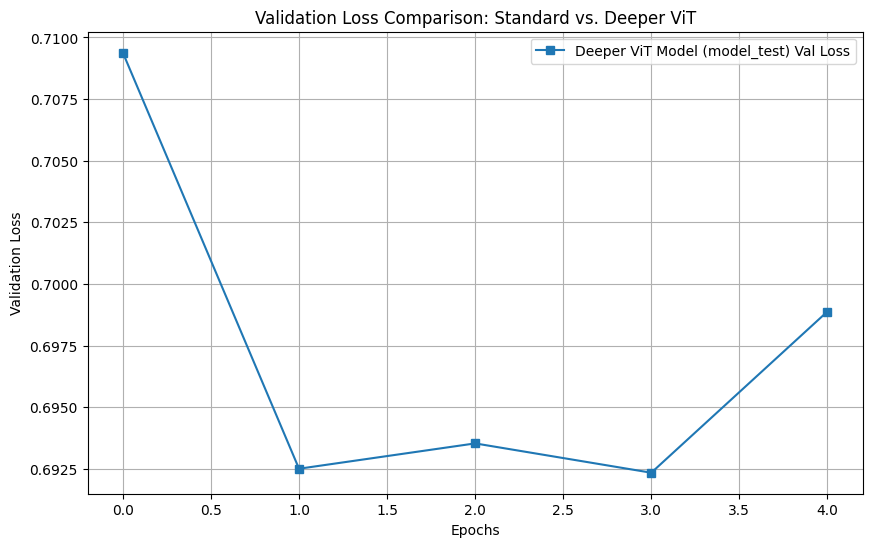

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# plt.plot(loss_history['val'], label='Original ViT Model Val Loss', marker='o')
plt.plot(
    loss_history_test['val'],
    label='Deeper ViT Model (model_test) Val Loss',
    marker='s',
)
plt.title('Validation Loss Comparison: Standard vs. Deeper ViT')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

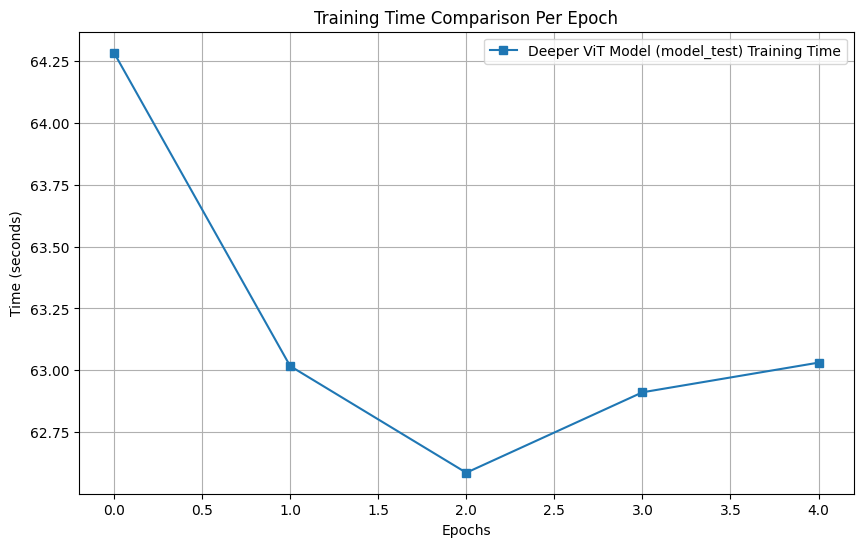

In [55]:
plt.figure(figsize=(10, 6))
# plt.plot(train_times, label='Original ViT Model Training Time', marker='o')
plt.plot(
    train_times_test,
    label='Deeper ViT Model (model_test) Training Time',
    marker='s',
)
plt.title('Training Time Comparison Per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

Question 9

In [56]:
import os
import torch

# Define dataset directory
extract_dir = "."
dataset_path = os.path.join(extract_dir, "images_dataSAT")

# DataLoader & Image Hyperparameters
img_size = 64  # Spatial dimensions (64x64 pixels)
img_w, img_h = 64, 64
in_channels = 3  # RGB color channels
batch_size = 128  # Batch size matching training setup
num_classes = 2  # Binary land classification (non-agri vs agri)
lr = 0.001

# Vision Transformer / Hybrid Model Hyperparameters
patch_size = 16  # Patch dimension (16x16 pixels)
embed_dim = 256  # Token embedding dimension
depth = 6  # Number of Transformer encoder blocks
num_heads = 8  # Multi-head self-attention heads
mlp_dim = 2048  # Feed-forward hidden dimension
drop_rate = 0.1  # Dropout regularization rate

agri_class_labels = ["non-agri", "agri"]
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dataset Path: {dataset_path} | Running evaluation on: {device}")

Dataset Path: ./images_dataSAT | Running evaluation on: cuda


In [57]:
# Instantiate the PyTorch Vision Transformer / CNN-ViT Hybrid model
pytorch_vit_model = VisionTransformer(
    img_size=img_size,
    patch_size=patch_size,
    in_channels=in_channels,
    num_classes=num_classes,
    embed_dim=embed_dim,
    depth=depth,
    num_heads=num_heads,
    mlp_dim=mlp_dim,
    drop_rate=drop_rate,
).to(device)

# Load saved best weights checkpoint if available
# pytorch_vit_model.load_state_dict(torch.load('pytorch_cnn_vit.pth'))
pytorch_vit_model.eval()
print("PyTorch CNN-ViT Hybrid Model successfully instantiated.")

PyTorch CNN-ViT Hybrid Model successfully instantiated.


In [58]:
# Print evaluation metrics for Keras CNN-ViT Hybrid Model
print_metrics(
    all_labels_keras_vit,
    all_preds_keras_vit,
    all_probs_keras_vit,
    agri_class_labels,
    "Keras CNN-Vit Hybrid Model",
)

NameError: name 'all_labels_keras_vit' is not defined